## 1. Imports

In [4]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt

from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM
from tensorflow.keras.layers import Embedding, Dropout, add

from tensorflow.keras.utils import to_categorical

## 2. Load Data

In [5]:
df = pd.read_csv(
    r"D:/flickr30k_images/results.csv",
    sep="|"
)
df.head()

,image_name,comment_number,comment
0,1000092795.jpg,0,Two young guys with shaggy hair look at their...
1,1000092795.jpg,1,"Two young , White males are outside near many..."
2,1000092795.jpg,2,Two men in green shirts are standing in a yard .
3,1000092795.jpg,3,A man in a blue shirt standing in a garden .
4,1000092795.jpg,4,Two friends enjoy time spent together .


## 3. Clean Captions

In [7]:
def clean_caption(text):
    text = text.lower()
    text = text.replace('[^A-Za-z]', ' ')
    text = text.replace('\s+', ' ')
    text = text.strip()

    return text

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
C:\Users\HP\AppData\Local\Temp\ipykernel_7600\4286762128.py:4: SyntaxWarning: invalid escape sequence '\s'
  text = text.replace('\s+', ' ')


In [9]:
captions_path = r"D:/flickr30k_images/results.csv"

df = pd.read_csv(
    captions_path,
    sep="|"
)

df.columns = df.columns.str.strip()

def clean_caption(text):
    text = str(text).lower()
    return text

df['comment'] = df['comment'].apply(clean_caption)

df.head()

,image_name,comment_number,comment
0,1000092795.jpg,0,two young guys with shaggy hair look at their...
1,1000092795.jpg,1,"two young , white males are outside near many..."
2,1000092795.jpg,2,two men in green shirts are standing in a yard .
3,1000092795.jpg,3,a man in a blue shirt standing in a garden .
4,1000092795.jpg,4,two friends enjoy time spent together .


## 4. Select Images

In [10]:
unique_images = df['image_name'].unique()

selected_images = unique_images[:5000]

df = df[df['image_name'].isin(selected_images)]

print("Number of selected images:", len(selected_images))

print("Dataset shape:", df.shape)

df.head()

Number of selected images: 5000
Dataset shape: (25000, 3)


,image_name,comment_number,comment
0,1000092795.jpg,0,two young guys with shaggy hair look at their...
1,1000092795.jpg,1,"two young , white males are outside near many..."
2,1000092795.jpg,2,two men in green shirts are standing in a yard .
3,1000092795.jpg,3,a man in a blue shirt standing in a garden .
4,1000092795.jpg,4,two friends enjoy time spent together .


## 5. Exploratory Data Analysis (EDA)

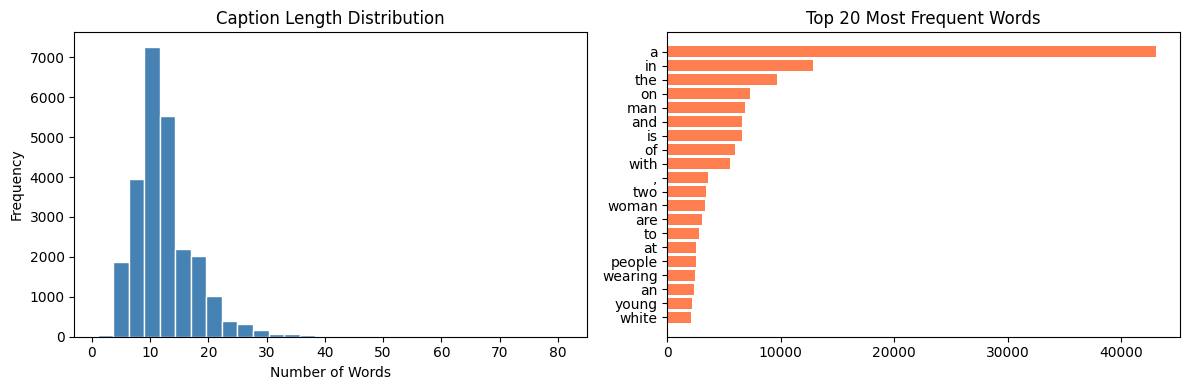

Average caption length : 12.2 words
Max caption length     : 81 words
Min caption length     : 1 words
Total unique images    : 5000
Total captions         : 25000


In [42]:
from collections import Counter
all_captions_raw = df['comment'].tolist()
lengths = [len(c.split()) for c in all_captions_raw]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(lengths, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Caption Length Distribution')
axes[0].set_xlabel('Number of Words')
axes[0].set_ylabel('Frequency')

all_words = ' '.join(all_captions_raw).split()
word_freq = Counter(all_words).most_common(20)
words, counts = zip(*word_freq)
axes[1].barh(words, counts, color='coral')
axes[1].set_title('Top 20 Most Frequent Words')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"Average caption length : {sum(lengths)/len(lengths):.1f} words")
print(f"Max caption length     : {max(lengths)} words")
print(f"Min caption length     : {min(lengths)} words")
print(f"Total unique images    : {df['image_name'].nunique()}")
print(f"Total captions         : {len(df)}")


## 6. Build Image-Caption Mapping

In [12]:
mapping = {}

for i in range(len(df)):
    image = df['image_name'].iloc[i]
    caption = df['comment'].iloc[i]

    if image not in mapping:
        mapping[image] = []

    mapping[image].append(caption)

In [13]:
for key in mapping:
    for i in range(len(mapping[key])):
        mapping[key][i] = "startseq " + mapping[key][i] + " endseq"

## 7. Tokenizer & Vocabulary

In [44]:
all_captions = []

for key in mapping:

    for cap in mapping[key]:

        all_captions.append(cap)

max_length = max(
    len(caption.split())
    for caption in all_captions
)

print(max_length)        

83


In [45]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(all_captions)

vocab_size = len(tokenizer.word_index) + 1
vocab_size

8580

## 8. VGG16 Feature Extraction

In [14]:
base_model = VGG16(weights="imagenet")

model = Model(
    inputs=base_model.input,
    outputs=base_model.layers[-2].output
)

In [15]:
images_path = r"D:/flickr30k_images/flickr30k_images"

features = {}

for img_name in tqdm(os.listdir(images_path)):

    if img_name not in selected_images:
        continue

    img_path = os.path.join(images_path, img_name)

    try:

        img = load_img(img_path, target_size=(224,224))

        img = img_to_array(img)

        img = np.expand_dims(img, axis=0)

        img = preprocess_input(img)

        feature = model.predict(img, verbose=0)

        features[img_name] = feature

    except:
        pass

100%|██████████| 31785/31785 [38:46<00:00, 13.66it/s]  


In [19]:
import pickle
pickle.dump(features, open("features.pkl", "wb"))

## 9. Prepare Training Sequences

In [47]:
X1, X2, y = [], [], []

for image, captions in mapping.items():

    if image not in features:
        continue

    feature = features[image][0]

    for caption in captions:

        seq = tokenizer.texts_to_sequences([caption])[0]

        for i in range(1, len(seq)):

            in_seq = seq[:i]

            out_seq = seq[i]

            in_seq = pad_sequences(
                [in_seq],
                maxlen=max_length
            )[0]

            X1.append(feature)

            X2.append(in_seq)

            y.append(out_seq)

X1 = np.array(X1)

X2 = np.array(X2)

y = np.array(y)

print(f"X1 shape: {X1.shape}")
print(f"X2 shape: {X2.shape}")
print(f"y  shape: {y.shape}")


X1 shape: (985, 4096)
X2 shape: (985, 83)
y  shape: (985,)


## 10. Train / Validation / Test Split

In [48]:
from sklearn.model_selection import train_test_split

# train = 80%
# validation + test = 20%

X1_train, X1_temp, X2_train, X2_temp, y_train, y_temp = train_test_split(
    X1,
    X2,
    y,
    test_size=0.2,
    random_state=42
)

# validation = 10%
# test = 10%

X1_val, X1_test, X2_val, X2_test, y_val, y_test = train_test_split(
    X1_temp,
    X2_temp,
    y_temp,
    test_size=0.5,
    random_state=42
)

print("Train:", X1_train.shape)

print("Validation:", X1_val.shape)

print("Test:", X1_test.shape)

Train: (788, 4096)
Validation: (98, 4096)
Test: (99, 4096)


## 11. Model Architecture (VGG16 + LSTM)

In [27]:
# IMAGE MODEL
inputs1 = Input(shape=(4096,))

fe1 = Dropout(0.5)(inputs1)

fe2 = Dense(256, activation='relu')(fe1)

# TEXT MODEL
inputs2 = Input(shape=(max_length,))

se1 = Embedding(
    vocab_size,
    256,
    mask_zero=True
)(inputs2)

se2 = Dropout(0.5)(se1)

se3 = LSTM(256)(se2)

# MERGE
decoder1 = add([fe2, se3])

decoder2 = Dense(
    256,
    activation='relu'
)(decoder1)

outputs = Dense(
    vocab_size,
    activation='softmax'
)(decoder2)

model = Model(
    inputs=[inputs1, inputs2],
    outputs=outputs
)


model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam'
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 83)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 4096)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 83, 256)   │  2,196,480 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 4096)      │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 83, 256)   │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 83)        │          0 │ input_layer_2[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │  1,048,832 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 256)       │    525,312 │ dropout_1[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256)       │          0 │ dense[0][0],      │
│                     │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │     65,792 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 8580)      │  2,205,060 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,041,476 (23.05 MB)

 Trainable params: 6,041,476 (23.05 MB)

 Non-trainable params: 0 (0.00 B)

## 12. Training

In [34]:
history = model.fit(
    [X1_train, X2_train],
    y_train,

    validation_data=(
        [X1_val, X2_val],
        y_val
    ),

    epochs=3,

    batch_size=64
)

Epoch 1/3
4098/4098 ━━━━━━━━━━━━━━━━━━━━ 1093s 265ms/step - accuracy: 0.2768 - loss: 4.4127 - val_accuracy: 0.3150 - val_loss: 3.9897
Epoch 2/3
4098/4098 ━━━━━━━━━━━━━━━━━━━━ 1003s 245ms/step - accuracy: 0.3253 - loss: 3.7063 - val_accuracy: 0.3315 - val_loss: 3.8489
Epoch 3/3
4098/4098 ━━━━━━━━━━━━━━━━━━━━ 1000s 244ms/step - accuracy: 0.3416 - loss: 3.4449 - val_accuracy: 0.3383 - val_loss: 3.8268


## 13. Training Curves

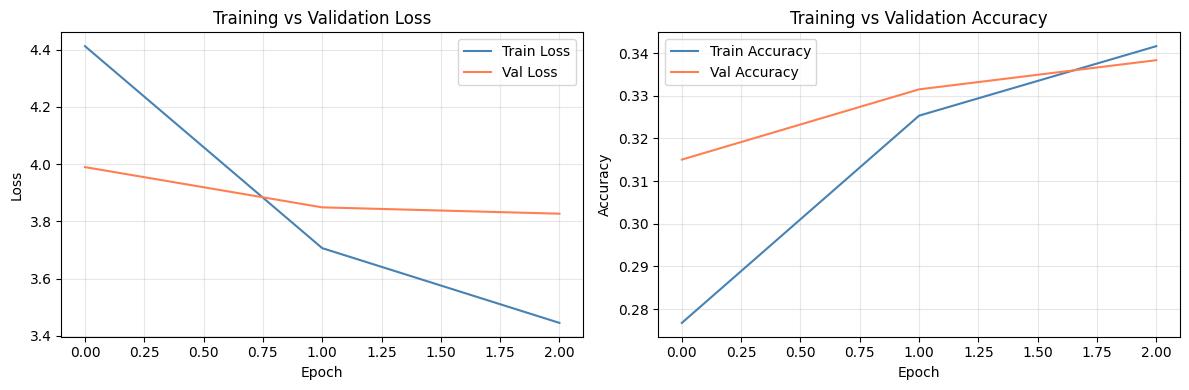

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'],     label='Train Loss',  color='steelblue')
axes[0].plot(history.history['val_loss'], label='Val Loss',    color='coral')
axes[0].set_title('Training vs Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'],     label='Train Accuracy', color='steelblue')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy',   color='coral')
axes[1].set_title('Training vs Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 14. Evaluation on Test Set

In [35]:
loss, acc = model.evaluate(
    [X1_test, X2_test],
    y_test
)

print("Test Loss:", loss)

print("Test Accuracy:", acc)

1025/1025 ━━━━━━━━━━━━━━━━━━━━ 49s 48ms/step - accuracy: 0.3394 - loss: 3.8263
Test Loss: 3.826328754425049
Test Accuracy: 0.33935272693634033


## 15. Caption Generation

In [39]:
def idx_to_word(integer, tokenizer):

    for word, index in tokenizer.word_index.items():

        if index == integer:
            return word

    return None
def predict_caption(model, image, tokenizer, max_length):

    in_text = "startseq"

    for i in range(max_length):

        sequence = tokenizer.texts_to_sequences([in_text])[0]

        sequence = pad_sequences(
            [sequence],
            maxlen=max_length
        )

        yhat = model.predict(
            [image, sequence],
            verbose=0
        )

        yhat = np.argmax(yhat)

        word = idx_to_word(yhat, tokenizer)

        if word is None:
            break

        in_text += " " + word

        if word == "endseq":
            break

    return in_text 

## 16. Sample Prediction

In [34]:
test_image = "1000092795.jpg"

feature = features[test_image]

caption = predict_caption(
    model,
    feature,
    tokenizer,
    max_length
)

print(caption)

startseq a man in a blue shirt is standing in front of a building endseq


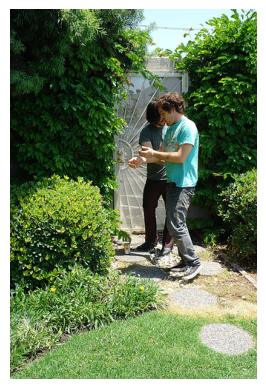

startseq a man in a blue shirt is standing in front of a building endseq


In [35]:
import matplotlib.pyplot as plt
from PIL import Image

img_path = os.path.join(
    images_path,
    test_image
)

img = Image.open(img_path)

plt.imshow(img)

plt.axis("off")

plt.show()

print(caption)  

## 17. BLEU Score Evaluation

In [40]:
import nltk
nltk.download('punkt', quiet=True)
from nltk.translate.bleu_score import corpus_bleu

def evaluate_bleu(model, mapping, features, tokenizer, max_length, n=200):
    actual, predicted = [], []
    sample_images = list(mapping.keys())[:n]

    for img_name in tqdm(sample_images, desc="Computing BLEU"):
        if img_name not in features:
            continue

        # الكابشنز الحقيقية بدون startseq/endseq
        refs = []
        for cap in mapping[img_name]:
            words = [w for w in cap.split() if w not in ('startseq', 'endseq')]
            refs.append(words)
        actual.append(refs)

        # الكابشن المتوقعة
        pred = predict_caption(model, features[img_name], tokenizer, max_length)
        pred_words = [w for w in pred.split() if w not in ('startseq', 'endseq')]
        predicted.append(pred_words)

    bleu1 = corpus_bleu(actual, predicted, weights=(1, 0, 0, 0))
    bleu2 = corpus_bleu(actual, predicted, weights=(0.5, 0.5, 0, 0))
    bleu4 = corpus_bleu(actual, predicted, weights=(0.25, 0.25, 0.25, 0.25))

    print(f"BLEU-1 : {bleu1:.4f}")
    print(f"BLEU-2 : {bleu2:.4f}")
    print(f"BLEU-4 : {bleu4:.4f}")
    return bleu1, bleu2, bleu4

bleu1, bleu2, bleu4 = evaluate_bleu(model, mapping, features, tokenizer, max_length)


Computing BLEU: 100%|██████████| 200/200 [00:24<00:00,  8.07it/s]

BLEU-1 : 0.5444
BLEU-2 : 0.3598
BLEU-4 : 0.1707
